In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from qutip import Qobj, fidelity, sigmax, sigmay, sigmaz

def plot_fidelity_on_bloch(rho1, rho2):
    # Define Bloch sphere
    fig = plt.figure()
    ax = Axes3D(fig)
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_surface(x, y, z, color='y', alpha=0.1, linewidth=0)

    # Calculate Bloch vectors
    bloch_vectors = [np.array([np.real(np.trace(Qobj(rho).full() @ sigmax)),
                               np.real(np.trace(Qobj(rho).full() @ sigmay)),
                               np.real(np.trace(Qobj(rho).full() @ sigmaz))])
                      for rho in [Qobj(rho1), Qobj(rho2)]]

    colors = ['red', 'blue']
    for vec, color in zip(bloch_vectors, colors):
        ax.plot([0, vec[0]], [0, vec[1]], [0, vec[2]], lw=2, c=color)

    # Calculate fidelity and plot text
    f = fidelity(Qobj(rho1), Qobj(rho2))
    ax.text(0, 0, 1.2, 'Fidelity = {:.2f}'.format(f))

    # Set plot limits and aspect
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])
    ax.set_box_aspect([1,1,1])

    # Set axis labels
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    plt.show()

c:\Users\Administrator\anaconda3\lib\site-packages\ipykernel_launcher.py:9: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  if __name__ == "__main__":


ValueError: matmul: Input operand 1 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

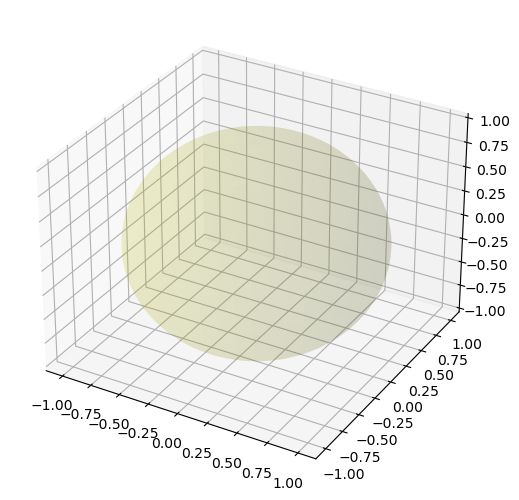

In [2]:
# Define two density matrices
rho1 = np.array([[0.5, 0.25], [0.25, 0.5]])
rho2 = np.array([[0.6, -0.15j], [0.15j, 0.4]])

# Plot fidelity on bloch sphere
plot_fidelity_on_bloch(rho1, rho2)